©2026. For information, contact Deloitte Tohmatsu Group.

# 📝 演習概要

この演習では、PyTorchを用いてSeq2Seq（Sequence-to-Sequence）モデルを実装し、チャットボットを構築します。Cornell映画コーパスを学習データとし、Encoder-Decoder構造にAttention機構を組み込んだモデルの実装を通じて、系列変換タスクの仕組みを学びます。

# 事前準備

[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

また実行完了後に「ランタイムの再起動」をして下さい．

（以下のセルの実行は、最初にしていただければ、以降必要ありません．）

In [ ]:
%%capture
# !pip uninstall matplotlib -y
# !pip install matplotlib==3.9.4

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.11.0.86

!pip uninstall torch -y
!pip install torch==2.7.0

# !pip uninstall torchvision -y
# !pip install torchvision==0.22.0

# pytorch を利用したRNN及びSeq2seqの実装

参考（Pytorch公式ドキュメント）：[RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)

## チャットボットの実装
実装したSeq2seq を利用して、チャットボットを構築します。

In [ ]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals

import torch
from torch.jit import script, trace
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import csv
import random
import re
import os
import unicodedata
import codecs
from io import open
import itertools
import math
import json


USE_CUDA = torch.cuda.is_available()
device = torch.device("cuda" if USE_CUDA else "cpu")

#### 学習データの取得

In [ ]:
# Convokitの映画コーパスをダウンロード・解凍・配置する。
!wget https://zissou.infosci.cornell.edu/convokit/datasets/movie-corpus/movie-corpus.zip
!unzip /content/movie-corpus.zip
!mkdir data
!mv "movie-corpus" data/

--2025-11-03 13:07:57--  https://zissou.infosci.cornell.edu/convokit/datasets/movie-corpus/movie-corpus.zip
Resolving zissou.infosci.cornell.edu (zissou.infosci.cornell.edu)... 128.253.51.179
Connecting to zissou.infosci.cornell.edu (zissou.infosci.cornell.edu)|128.253.51.179|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40854701 (39M) [application/zip]
Saving to: ‘movie-corpus.zip’

movie-corpus.zip    100%[===================>]  38.96M  25.7MB/s    in 1.5s    

2025-11-03 13:07:59 (25.7 MB/s) - ‘movie-corpus.zip’ saved [40854701/40854701]

Archive:  /content/movie-corpus.zip
   creating: movie-corpus/
  inflating: movie-corpus/utterances.jsonl  
  inflating: movie-corpus/conversations.json  
  inflating: movie-corpus/corpus.json  
  inflating: movie-corpus/speakers.json  
  inflating: movie-corpus/index.json  


In [ ]:
corpus_name = "movie-corpus"
corpus = os.path.join("/content/data", corpus_name)

def printLines(file, n=10):
    # 指定ファイルから先頭n行を読み込んで表示するデバッグ用関数
    with open(file, 'rb') as datafile:
        lines = datafile.readlines()
    for line in lines[:n]:
        print(line)

printLines(os.path.join(corpus, "utterances.jsonl"))

b'{"id": "L1045", "conversation_id": "L1044", "text": "They do not!", "speaker": "u0", "meta": {"movie_id": "m0", "parsed": [{"rt": 1, "toks": [{"tok": "They", "tag": "PRP", "dep": "nsubj", "up": 1, "dn": []}, {"tok": "do", "tag": "VBP", "dep": "ROOT", "dn": [0, 2, 3]}, {"tok": "not", "tag": "RB", "dep": "neg", "up": 1, "dn": []}, {"tok": "!", "tag": ".", "dep": "punct", "up": 1, "dn": []}]}]}, "reply-to": "L1044", "timestamp": null, "vectors": []}\n'
b'{"id": "L1044", "conversation_id": "L1044", "text": "They do to!", "speaker": "u2", "meta": {"movie_id": "m0", "parsed": [{"rt": 1, "toks": [{"tok": "They", "tag": "PRP", "dep": "nsubj", "up": 1, "dn": []}, {"tok": "do", "tag": "VBP", "dep": "ROOT", "dn": [0, 2, 3]}, {"tok": "to", "tag": "TO", "dep": "dobj", "up": 1, "dn": []}, {"tok": "!", "tag": ".", "dep": "punct", "up": 1, "dn": []}]}]}, "reply-to": null, "timestamp": null, "vectors": []}\n'
b'{"id": "L985", "conversation_id": "L984", "text": "I hope so.", "speaker": "u0", "meta": {

#### 処理に適した形のデータファイルの作成


In [ ]:
# ファイルの各行を分割して、行と会話を作成する
def loadLinesAndConversations(fileName):
    lines = {}
    conversations = {}
    with open(fileName, 'r', encoding='iso-8859-1') as f:
        for line in f:
            lineJson = json.loads(line)
            # ラインオブジェクトのフィールドを抽出する
            lineObj = {}
            lineObj["lineID"] = lineJson["id"]            # 発話ID
            lineObj["characterID"] = lineJson["speaker"]  # 話者ID
            lineObj["text"] = lineJson["text"]            # 実際のテキスト
            lines[lineObj['lineID']] = lineObj            # lineIDをキーに保存

            # 会話オブジェクトのフィールドを抽出する
            if lineJson["conversation_id"] not in conversations:
                convObj = {}
                convObj["conversationID"] = lineJson["conversation_id"]
                convObj["movieID"] = lineJson["meta"]["movie_id"]
                convObj["lines"] = [lineObj]
            else:
                convObj = conversations[lineJson["conversation_id"]]
                convObj["lines"].insert(0, lineObj)
            conversations[convObj["conversationID"]] = convObj

    return lines, conversations


# 会話から文のペアを抽出する
def extractSentencePairs(conversations):
    qa_pairs = []
    for conversation in conversations.values():
        # 会話の全行程を反復する
        for i in range(len(conversation["lines"]) - 1):
            inputLine = conversation["lines"][i]["text"].strip()
            targetLine = conversation["lines"][i+1]["text"].strip()
            # 間違ったサンプルをフィルタリングする（リストの1つが空である場合）
            if inputLine and targetLine:
                qa_pairs.append([inputLine, targetLine])
    return qa_pairs

In [ ]:
# 新しいファイルへのパスを定義する
datafile = os.path.join(corpus, "formatted_movie_lines.txt")

delimiter = '\t'
# delimiterを解除する
delimiter = str(codecs.decode(delimiter, "unicode_escape"))

# 行のdictと会話のdictを初期化する
lines = {}
conversations = {}
# ロードラインと会話
print("\nProcessing corpus into lines and conversations...")
lines, conversations = loadLinesAndConversations(os.path.join(corpus, "utterances.jsonl"))
# utterances.jsonl から lines / conversations を構築

# 新しいcsvファイルを書き込む
print("\nWriting newly formatted file...")
with open(datafile, 'w', encoding='utf-8') as outputfile:
    writer = csv.writer(outputfile, delimiter=delimiter, lineterminator='\n')
    for pair in extractSentencePairs(conversations):
        writer.writerow(pair)
        # 各会話から抽出した(発話,返答)ペアをタブ区切りで1行ずつ書き出し

# サンプルを表示する
print("\nSample lines from file:")
printLines(datafile)
# formatted_movie_lines.txt の先頭数行をバイナリ読み＆printで確認


Processing corpus into lines and conversations...

Writing newly formatted file...

Sample lines from file:
b'They do to!\tThey do not!\n'
b'She okay?\tI hope so.\n'
b"Wow\tLet's go.\n"
b'"I\'m kidding.  You know how sometimes you just become this ""persona""?  And you don\'t know how to quit?"\tNo\n'
b"No\tOkay -- you're gonna need to learn how to lie.\n"
b"I figured you'd get to the good stuff eventually.\tWhat good stuff?\n"
b'What good stuff?\t"The ""real you""."\n'
b'"The ""real you""."\tLike my fear of wearing pastels?\n'
b'do you listen to this crap?\tWhat crap?\n'
b"What crap?\tMe.  This endless ...blonde babble. I'm like, boring myself.\n"


#### データのロードと非頻出単語のトリミング

In [ ]:
# デフォルトのワードトークン
PAD_token = 0  # パディングの token
SOS_token = 1  # 文章のはじまりの token
EOS_token = 2  # 文章の終わりの token

# 単語からインデックスへのマッピング、
# インデックスから単語への逆マッピング、各単語の数、および合計単語数を
# 保持するクラス
class Voc:
    def __init__(self, name):
        self.name = name
        self.trimmed = False      # 一度trim()して低頻度語を削ったかどうかのフラグ
        self.word2index = {}
        self.word2count = {}
        self.index2word = {PAD_token: "PAD", SOS_token: "SOS", EOS_token: "EOS"}
        self.num_words = 3    # SOS, EOS, PAD

    def addSentence(self, sentence):
        # 文を空白でsplitし、各単語をaddWord()する
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        # 新規単語ならIDを割り当て、出現回数(word2count)も1で初期化。
        # 既知の単語ならカウントだけ+1。
        if word not in self.word2index:
            self.word2index[word] = self.num_words
            self.word2count[word] = 1
            self.index2word[self.num_words] = word
            self.num_words += 1
        else:
            self.word2count[word] += 1

    # しきい値以下の単語を取り外す（非頻出単語の削除）
    def trim(self, min_count):
        # min_count 回未満しか出ないレア単語は語彙から除外し語彙を縮小する
        if self.trimmed:
            return
        self.trimmed = True

        keep_words = []

        for k, v in self.word2count.items():
            if v >= min_count:
                keep_words.append(k)
        # keep_words: 指定回数以上出現した単語のみ

        print('keep_words {} / {} = {:.4f}'.format(
            len(keep_words), len(self.word2index), len(keep_words) / len(self.word2index)
        ))
        # どれくらい語彙が残ったかのログ

        # 初期化し直して、特殊トークンのみ再セット
        self.word2index = {}
        self.word2count = {}
        self.index2word = {PAD_token: "PAD", SOS_token: "SOS", EOS_token: "EOS"}
        self.num_words = 3 # SOS, EOS, PAD

        for word in keep_words:
            self.addWord(word)
        #~ 残す単語だけでもう一度IDを振り直す

In [ ]:
MAX_LENGTH = 10  # 最大文長

# Unicode文字列をプレーンASCIIに変換する
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# 小文字化、文字以外をトリミング
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)              # 句読点の前後にスペース確保 ("hi!"→"hi !")
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)          # 英字と .!? 以外は空白に置換
    s = re.sub(r"\s+", r" ", s).strip()            # 連続スペース→1スペース、前後の空白除去
    return s

# クエリと応答のペアを読み取り、vocオブジェクトを返します
def readVocs(datafile, corpus_name):
    print("Reading lines...")
    # ファイルを読み取り、行に分割します
    lines = open(datafile, encoding='utf-8').\
        read().strip().split('\n')
    # すべての行をペアに分割し、正規化します
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]
    voc = Voc(corpus_name)
    return voc, pairs

# ペア「p」の両方の文がMAX_LENGTHを下回っている場合にTrueを返します
def filterPair(p):
    # 入力シーケンスは、EOSトークンの最後の単語を保持する必要があります
    return len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH

# ペアをフィルターします
def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

# 上で定義された関数を使用して、入力されたvocオブジェクトとペアのリストを返します
def loadPrepareData(corpus, corpus_name, datafile, save_dir):
    # データの前処理一式をまとめたヘルパー
    print("Start preparing training data ...")
    voc, pairs = readVocs(datafile, corpus_name)
    print("Read {!s} sentence pairs".format(len(pairs)))
    pairs = filterPairs(pairs)
    print("Trimmed to {!s} sentence pairs".format(len(pairs)))
    # 長すぎるペアを除いた残りの件数
    print("Counting words...")
    # 残ったペアを使って語彙vocに単語を登録してカウントしていく
    for pair in pairs:
        voc.addSentence(pair[0])
        voc.addSentence(pair[1])
    print("Counted words:", voc.num_words)
    # voc.num_words は特殊トークンを含む総語彙サイズ
    return voc, pairs

save_dir = os.path.join("/content/data", "save")
voc, pairs = loadPrepareData(corpus, corpus_name, datafile, save_dir)
print("\npairs:")
for pair in pairs[:10]:
    print(pair)
# 前処理後の最初の10ペアを表示してデータ内容を確認

Start preparing training data ...
Reading lines...
Read 221282 sentence pairs
Trimmed to 64313 sentence pairs
Counting words...
Counted words: 18082

pairs:
['they do to !', 'they do not !']
['she okay ?', 'i hope so .']
['wow', 'let s go .']
['what good stuff ?', 'the real you .']
['the real you .', 'like my fear of wearing pastels ?']
['do you listen to this crap ?', 'what crap ?']
['well no . . .', 'then that s all you had to say .']
['then that s all you had to say .', 'but']
['but', 'you always been this selfish ?']
['have fun tonight ?', 'tons']


In [ ]:
MIN_COUNT = 3    # トリミングの最小単語数のしきい値

def trimRareWords(voc, pairs, MIN_COUNT):
    # MIN_COUNT以下しか使用されていない単語をvocから削除します
    voc.trim(MIN_COUNT)
    # voc内で低頻度語を消して語彙を再構成する

    # トリミングされた単語でペアを除外する
    keep_pairs = []
    for pair in pairs:
        input_sentence = pair[0]
        output_sentence = pair[1]
        keep_input = True
        keep_output = True
        # 入力文を確認してください
        for word in input_sentence.split(' '):
            if word not in voc.word2index:
                #　vocに残っていない単語があればこのペアは破棄
                keep_input = False
                break
        # 出力文を確認する
        for word in output_sentence.split(' '):
            if word not in voc.word2index:
                keep_output = False
                break

        # 入力文または出力文にトリミングされた単語を含まないペアのみを保持します
        if keep_input and keep_output:
            keep_pairs.append(pair)

    print("Trimmed from {} pairs to {}, {:.4f} of total".format(len(pairs), len(keep_pairs), len(keep_pairs) / len(pairs)))
    # どれくらいのペアが語彙縮小で残ったかログ表示
    return keep_pairs

pairs = trimRareWords(voc, pairs, MIN_COUNT)

keep_words 7833 / 18079 = 0.4333
Trimmed from 64313 pairs to 53131, 0.8261 of total


#### データの準備

In [ ]:
def indexesFromSentence(voc, sentence):
    # 文を単語ID列に変換し、最後に EOS_token を追加する
    return [voc.word2index[word] for word in sentence.split(' ')] + [EOS_token]


def zeroPadding(l, fillvalue=PAD_token):
    # 可変長のID列をPAD_tokenでパディングして同じ長さに揃える
    return list(itertools.zip_longest(*l, fillvalue=fillvalue))

def binaryMatrix(l, value=PAD_token):
    # パディング位置を0、それ以外を1とするマスクを作る
    # shapeは zeroPadding() と同じ並び(タイムステップ×バッチ)
    m = []
    for i, seq in enumerate(l):
        m.append([])
        for token in seq:
            if token == PAD_token:
                m[i].append(0)  # PADなら0
            else:
                m[i].append(1)  # 実トークンなら1
    return m

# 埋め込み入力シーケンステンソルと長さを返します
def inputVar(l, voc):
    # l: 入力文のバッチ (文字列リスト)
    # 1) 各文をID列+EOSに変換
    indexes_batch = [indexesFromSentence(voc, sentence) for sentence in l]
    # 2) 各文の長さ（EOS込み）をテンソル化
    lengths = torch.tensor([len(indexes) for indexes in indexes_batch])
    # 3) PADで右詰めして行列化(系列長×バッチ)
    padList = zeroPadding(indexes_batch)
    padVar = torch.LongTensor(padList)
    return padVar, lengths

# パディングされたターゲットシーケンステンソル、パディングマスク、および最大ターゲット長を返します
def outputVar(l, voc):
    # l: 応答文のバッチ (文字列リスト)
    indexes_batch = [indexesFromSentence(voc, sentence) for sentence in l]
    max_target_len = max([len(indexes) for indexes in indexes_batch])
    # 応答の最大長(デコーダのループ回数などで使う)

    padList = zeroPadding(indexes_batch)  # PADで整列
    mask = binaryMatrix(padList)          # PAD位置=0 のマスク
    mask = torch.BoolTensor(mask)         # (max_seq_len, batch_size) のboolマスク
    padVar = torch.LongTensor(padList)    # 実際のターゲットID列 (PAD込み)
    return padVar, mask, max_target_len

# ペアの指定されたバッチのすべてのアイテムを返します
def batch2TrainData(voc, pair_batch):
    # pair_batch: [["hi how are you", "fine thanks"], ...] のリスト(バッチ)
    # これを学習で扱いやすい形(入力, 出力, 長さ, マスクなど)にまとめる
    pair_batch.sort(key=lambda x: len(x[0].split(" ")), reverse=True)
    # 長い入力文順にソート (RNN系でpacked sequence使う場合などの慣習)
    input_batch, output_batch = [], []
    for pair in pair_batch:
        input_batch.append(pair[0])   # ユーザ側(質問側)
        output_batch.append(pair[1])  # 応答側
    inp, lengths = inputVar(input_batch, voc)              # エンコーダ入力系列+長さ
    output, mask, max_target_len = outputVar(output_batch, voc)  # デコーダ用ターゲット+マスク
    return inp, lengths, output, mask, max_target_len

# 検証
small_batch_size = 5
batches = batch2TrainData(voc, [random.choice(pairs) for _ in range(small_batch_size)])
# pairs からランダムに5組取り出して、上の整形関数を通してみる
input_variable, lengths, target_variable, mask, max_target_len = batches

print("input_variable:", input_variable)
print("lengths:", lengths)
print("target_variable:", target_variable)
print("mask:", mask)
print("max_target_len:", max_target_len)

input_variable: tensor([[  31,  128,   19,   34,  103],
        [  69,  280,    6,   14,   10],
        [ 386,   11,  590,    2,    2],
        [  52,   83,    6,    0,    0],
        [1480,   13,    2,    0,    0],
        [3668,   14,    0,    0,    0],
        [ 217,    2,    0,    0,    0],
        [   2,    0,    0,    0,    0]])
lengths: tensor([8, 7, 5, 3, 3])
target_variable: tensor([[ 101,  257,   85,   90,   20],
        [  62,   58,   17,   31,  647],
        [4162, 3629,   19,   10,   14],
        [ 684,  187,   24,    2,   24],
        [ 388,   85,   94,    0, 1803],
        [  14, 1383,  324,    0,   22],
        [   2,   14,  135,    0, 4568],
        [   0,    2,   85,    0,   14],
        [   0,    0,   10,    0,    2],
        [   0,    0,    2,    0,    0]])
mask: tensor([[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  Tr

### Seq２seq

参考（Pytorch公式ドキュメント）：　[CHATBOT TUTORIAL](https://pytorch.org/tutorials/beginner/chatbot_tutorial.html)

Pytorch の基本モジュールを利用して、Seq2seq を実装します。  


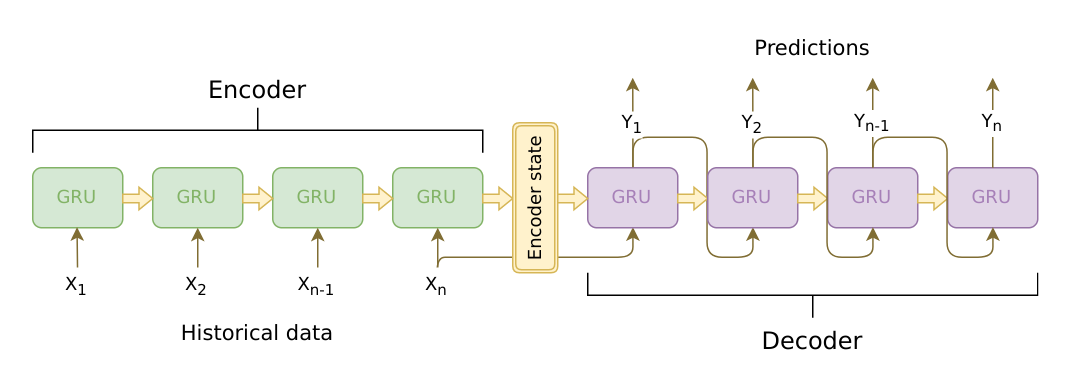

### Encoder

双方向型にした GRU を利用して Encoder を作成します。

#### 入力型  
input_seq: 入力データ長 ; shape=(max_length, batch_size)  
input_lengths: バッチ内のセンテンスの長さ ; shape=(batch_size)  
hidden: 隠れ層 ; shape=(n_layers x num_directions, batch_size, hidden_size)  


#### 出力型  
outputs: 最終隠れ層の出力型 ; shape=(max_length, batch_size, hidden_size)  
hidden: 隠れ層の状態 ; shape=(n_layers x num_directions, batch_size, hidden_size)

In [ ]:
class EncoderRNN(nn.Module):
    def __init__(self, hidden_size, embedding, n_layers=1, dropout=0):
        super(EncoderRNN, self).__init__()
        self.n_layers = n_layers
        self.hidden_size = hidden_size
        self.embedding = embedding

        # GRUの初期化
        # 入力データのエンベディング時の特徴量の数は隠れ層の大きさになるため、
        # 'input_size' と 'hidden_size' のパラメータは 'hidden_size' に依存します。
        # ※双方向型にするため、bidirectional=True にしています。
        self.gru = nn.GRU(hidden_size, hidden_size, n_layers,
                          dropout=(0 if n_layers == 1 else dropout), bidirectional=True)

    def forward(self, input_seq, input_lengths, hidden=None):
        # 入力データをエンベディングします。
        embedded = self.embedding(input_seq)
        # シークエンス長を一定にするために、パディングします。
        packed = nn.utils.rnn.pack_padded_sequence(embedded, input_lengths)
        # GRU に順伝播します。
        outputs, hidden = self.gru(packed, hidden)
        # パディングをもとに戻します。
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs)
        # 双方向をひとつにまとめます。
        outputs = outputs[:, :, :self.hidden_size] + outputs[:, : ,self.hidden_size:]
        # アウトプットと隠れ層を戻り値にします。
        return outputs, hidden

### Decoder
Attention を利用した Decoder を実装します。  

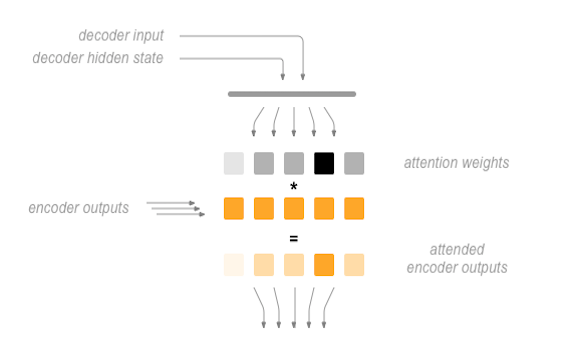

##### Attention
通常の Attention を改良し、より的確に情報を引き出せるようにした Global attention を利用します。

In [ ]:
# Attention クラスをまず設定します。
class Attn(nn.Module):
    # Luong Attention で使う「どこを見ればいいか」の重み（アテンション重み）を計算するモジュール
    def __init__(self, method, hidden_size):
        super(Attn, self).__init__()
        self.method = method
        if self.method not in ['dot', 'general', 'concat']:
            # 想定外のアテンション手法が指定されたらエラー
            raise ValueError(self.method, "is not an appropriate attention method.")
        self.hidden_size = hidden_size

        # Luongの3種のスコア関数に合わせて追加パラメータを定義
        if self.method == 'general':
            # general: score(h_t, h_s) = h_t^T * W_a * h_s
            self.attn = nn.Linear(self.hidden_size, hidden_size)
        elif self.method == 'concat':
            # concat: score(h_t, h_s) = v_a^T * tanh(W_a * [h_t ; h_s])
            self.attn = nn.Linear(self.hidden_size * 2, hidden_size)
            self.v = nn.Parameter(torch.FloatTensor(hidden_size))

    def dot_score(self, hidden, encoder_output):
        # hidden: (1, batch, hidden_size)   デコーダ現在時刻の隠れ状態
        # encoder_output: (seq_len, batch, hidden_size) エンコーダ各時刻の隠れ状態
        return torch.sum(hidden * encoder_output, dim=2)

    def general_score(self, hidden, encoder_output):
        # general方式のスコア計算
        # encoder_outputに線形変換をかけてから dot_score 的に内積をとる
        energy = self.attn(encoder_output)
        return torch.sum(hidden * energy, dim=2)

    def concat_score(self, hidden, encoder_output):
        # concat方式のスコア計算
        # hidden を seq_len 分だけ複製して encoder_output と結合 → 線形→tanh→vとの内積
        energy = self.attn(torch.cat((hidden.expand(encoder_output.size(0), -1, -1), encoder_output), 2)).tanh()
        return torch.sum(self.v * energy, dim=2)  # v と要素積を取って和をとる

    def forward(self, hidden, encoder_outputs):
        # hidden: (1, batch, hidden_size)    デコーダの現在の隠れ状態
        # encoder_outputs: (seq_len, batch, hidden_size) エンコーダ全時刻の隠れ状態
        # この2つから「各エンコーダ時刻がどれだけ重要か」を表すアテンション重みを出す

        # 状況に応じて計算する仕組みを変更するようにします。（Global Attention）
        if self.method == 'general':
            attn_energies = self.general_score(hidden, encoder_outputs)
        elif self.method == 'concat':
            attn_energies = self.concat_score(hidden, encoder_outputs)
        elif self.method == 'dot':
            attn_energies = self.dot_score(hidden, encoder_outputs)

        # 転置します。
        attn_energies = attn_energies.t()

        # 次元を追加して出力を返します
        # softmaxで正規化して確率にする (どの時刻を見るかの分布)
        return F.softmax(attn_energies, dim=1).unsqueeze(1)

#### Attention を利用した Decoder

入力型:

input_step: 入力シーケンスバッチの1つのタイムステップ（1ワード）; shape=(1, batch_size)  
last_hidden: GRUの最後の隠し層; shape=(n_layers x num_directions, batch_size, hidden_size)  
encoder_outputs: エンコーダモデルの出力; shape=(max_length, batch_size, hidden_size)  

出力型:

output: 各単語がデコードされたシーケンスの正しい次の単語である確率を与えるsoftmax正規化テンソル; shape=(batch_size, voc.num_words)  
hidden: GRUの最終隠れ層の状態; shape=(n_layers x num_directions, batch_size, hidden_size)

In [ ]:
class LuongAttnDecoderRNN(nn.Module):
    # Luong Attention 型のデコーダRNN(GRU)。
    # 1ステップずつ次の単語を生成する。
    def __init__(self, attn_model, embedding, hidden_size, output_size,
                 n_layers=1, dropout=0.1):
        super(LuongAttnDecoderRNN, self).__init__()

        # Keep for reference
        self.attn_model = attn_model          # 'dot' / 'general' / 'concat'
        self.hidden_size = hidden_size        # 隠れ層サイズ
        self.output_size = output_size        # 語彙サイズ（出力クラス数）
        self.n_layers = n_layers              # GRUの層数
        self.dropout = dropout                # Dropout率

        # 層を定義する
        self.embedding = embedding            # 単語ID -> 埋め込みベクトル(nn.Embedding想定)
        self.embedding_dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(
            hidden_size,                      # 入力サイズ(=埋め込みサイズと合わせる設計)
            hidden_size,                      # 隠れ状態サイズ
            n_layers,
            dropout=(0 if n_layers == 1 else dropout)
        )
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        # rnn出力とコンテキストを結合したものを変換する線形層

        self.out = nn.Linear(hidden_size, output_size)
        # 最終的に各単語IDに対するロジットを出す全結合層

        self.attn = Attn(attn_model, hidden_size)
        # 上で定義したAttention機構を内部に持つ

    def forward(self, input_step, last_hidden, encoder_outputs):
        # 注：一度に1ステップ（ワード）ずつ実行します。
        # 現在の入力語の埋め込みを取得する
        embedded = self.embedding(input_step)          # -> (1,batch,hidden_size想定)
        embedded = self.embedding_dropout(embedded)    # dropoutで正則化
        # 一方向GRUによるフォワード
        rnn_output, hidden = self.gru(embedded, last_hidden)
        # 現在のGRUの出力から重みを計算する
        attn_weights = self.attn(rnn_output, encoder_outputs)
        # エンコーダ出力に注目の重みをかけ、新しい「重み付き和」コンテキストベクトルを得る
        context = attn_weights.bmm(encoder_outputs.transpose(0, 1))
        # 重み付きコンテキストベクトルとGRU出力を結合する。
        rnn_output = rnn_output.squeeze(0)
        context = context.squeeze(1)
        concat_input = torch.cat((rnn_output, context), 1)
        concat_output = torch.tanh(self.concat(concat_input))
        # 次の単語を予測する。
        output = self.out(concat_output)          # (batch,output_size=語彙数)
        output = F.softmax(output, dim=1)         # 単語ごとの確率分布に変換
        # 出力と最終的な隠れ状態を返す
        return output, hidden

### 損失関数の設定

In [ ]:
def maskNLLLoss(inp, target, mask):
    nTotal = mask.sum()  # 有効なトークン数
    # CrossEntropyを独自に手計算している:
    # -torch.log(P(correct_class))
    crossEntropy = -torch.log(
        torch.gather(inp, 1, target.view(-1, 1)).squeeze(1)
        # torch.gatherで正解IDの確率だけ取り出す
    )
    # mask==1 の部分だけを抽出して平均
    loss = crossEntropy.masked_select(mask).mean()
    loss = loss.to(device)
    return loss, nTotal.item()

### 勾配クリッピングの実装
Pytorch では勾配クリッピングは以下のようにライブラリーを利用することで簡単に実装することができる。

参考（Pytorch 公式ドキュメント）： [TORCH.NN.UTILS.CLIP_GRAD_NORM_](https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html)


#### 学習

学習できるように関数を定義します

In [ ]:
def train(input_variable, lengths, target_variable, mask, max_target_len, encoder, decoder, embedding,
          encoder_optimizer, decoder_optimizer, batch_size, clip, max_length=MAX_LENGTH):

    # 勾配の初期化
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    # デバイスオプションを設定します
    input_variable = input_variable.to(device)        # エンコーダ入力をGPU/CPUへ
    target_variable = target_variable.to(device)
    mask = mask.to(device)
    # rnnの長さは、常にCPU上にある必要があります
    lengths = lengths.to("cpu")

    # 変数の初期化
    loss = 0
    print_losses = []  # ログ用: タイムステップごとのloss * 有効token数
    n_totals = 0       # ログ用: 有効token数の合計

    # エンコーダー
    encoder_outputs, encoder_hidden = encoder(input_variable, lengths)

    # 初期デコーダー入力を作成します（各文のSOSトークンで開始します）
    decoder_input = torch.LongTensor([[SOS_token for _ in range(batch_size)]])
    decoder_input = decoder_input.to(device)

    # デコーダーの一層目をエンコーダーの最終隠れ層に接続します
    decoder_hidden = encoder_hidden[:decoder.n_layers]
    # エンコーダが多層双方向などの場合、decoderが必要とする層数/方向分だけを取り出す

    # 教師強制を使用しているかどうかを判断します
    use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

    # 一度に1タイムステップずつデコーダーを介してシーケンスのバッチを転送します
    if use_teacher_forcing:
        for t in range(max_target_len):
            decoder_output, decoder_hidden = decoder(
                decoder_input, decoder_hidden, encoder_outputs
            )
            # 教師強制：次の入力を現在のターゲットにします
            decoder_input = target_variable[t].view(1, -1)
            # ロスの計算
            mask_loss, nTotal = maskNLLLoss(decoder_output, target_variable[t], mask[t])
            loss += mask_loss
            print_losses.append(mask_loss.item() * nTotal)
            n_totals += nTotal
    else:
        for t in range(max_target_len):
            decoder_output, decoder_hidden = decoder(
                decoder_input, decoder_hidden, encoder_outputs
            )
            # 非教師強制: 次の入力を自身の出力にします
            _, topi = decoder_output.topk(1)
            decoder_input = torch.LongTensor([[topi[i][0] for i in range(batch_size)]])
            decoder_input = decoder_input.to(device)
            # ロスの計算
            mask_loss, nTotal = maskNLLLoss(decoder_output, target_variable[t], mask[t])
            loss += mask_loss
            print_losses.append(mask_loss.item() * nTotal)
            n_totals += nTotal

    # 逆伝播を実行します
    loss.backward()

    # クリップグラデーション
    _ = nn.utils.clip_grad_norm_(encoder.parameters(), clip)
    _ = nn.utils.clip_grad_norm_(decoder.parameters(), clip)

    # モデルの重みを調整する
    encoder_optimizer.step()
    decoder_optimizer.step()

    return sum(print_losses) / n_totals

#### イテレーション

In [ ]:
def trainIters(model_name, voc, pairs, encoder, decoder, encoder_optimizer, decoder_optimizer, embedding, encoder_n_layers, decoder_n_layers, save_dir, n_iteration, batch_size, print_every, save_every, clip, corpus_name, loadFilename):

    # バッチをロードします
    training_batches = [batch2TrainData(voc, [random.choice(pairs) for _ in range(batch_size)])
                      for _ in range(n_iteration)]
    # 初期化
    print('Initializing ...')
    start_iteration = 1
    print_loss = 0
    if loadFilename:
        start_iteration = checkpoint['iteration'] + 1

    # 学習
    print("Training...")
    for iteration in range(start_iteration, n_iteration + 1):
        training_batch = training_batches[iteration - 1]
        # バッチからフィールドを抽出する
        input_variable, lengths, target_variable, mask, max_target_len = training_batch

        # バッチ単位で学習する
        loss = train(input_variable, lengths, target_variable, mask, max_target_len, encoder,
                     decoder, embedding, encoder_optimizer, decoder_optimizer, batch_size, clip)
        print_loss += loss

        # 進捗の表示
        if iteration % print_every == 0:
            print_loss_avg = print_loss / print_every
            print("Iteration: {}; Percent complete: {:.1f}%; Average loss: {:.4f}".format(iteration, iteration / n_iteration * 100, print_loss_avg))
            # 何イテレーション目か、全体の何％進んだか、直近print_every回の平均loss
            print_loss = 0

        # 重みの保存
        if (iteration % save_every == 0):
            # チェックポイントを定期的に保存する
            directory = os.path.join(save_dir, model_name, corpus_name, '{}-{}_{}'.format(encoder_n_layers, decoder_n_layers, hidden_size))
            if not os.path.exists(directory):
                os.makedirs(directory)
            torch.save({
                'iteration': iteration,                      # どこまで学習したか
                'en': encoder.state_dict(),                  # encoderの重み
                'de': decoder.state_dict(),                  # decoderの重み
                'en_opt': encoder_optimizer.state_dict(),    # encoder optimizerの状態
                'de_opt': decoder_optimizer.state_dict(),    # decoder optimizerの状態
                'loss': loss,                                # 直近のloss
                'voc_dict': voc.__dict__,                    # 語彙そのもの(再現用)
                'embedding': embedding.state_dict()          # 埋め込み層の重み
            }, os.path.join(directory, '{}_{}.tar'.format(iteration, 'checkpoint')))

#### グリーディデコード
グリーディデコードは、教師強制を使用していないときに学習中に使用するデコーディング手法です。  

タイムステップごとに、softmax値が最も高いdecoder_outputから単語を選択するだけです。  
このデコード方法は、単一のタイムステップレベルで最適です。

In [ ]:
class GreedySearchDecoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(GreedySearchDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, input_seq, input_length, max_length):
        # エンコーダモデルを介した順伝播
        encoder_outputs, encoder_hidden = self.encoder(input_seq, input_length)
        # エンコーダの最後の隠しレイヤーを、デコーダへの最初の隠し入力になるように準備します
        decoder_hidden = encoder_hidden[:decoder.n_layers]
        # SOS_tokenでデコーダへの入力を初期化します
        decoder_input = torch.ones(1, 1, device=device, dtype=torch.long) * SOS_token
        # テンソルを初期化して、デコードされた単語を追加します
        all_tokens = torch.zeros([0], device=device, dtype=torch.long)
        all_scores = torch.zeros([0], device=device)
        # 一度に1つの単語トークンを繰り返しデコードします
        for _ in range(max_length):
            # デコーダモデルを介した順伝播
            decoder_output, decoder_hidden = self.decoder(decoder_input, decoder_hidden, encoder_outputs)
            # 最も可能性の高い単語トークンとそのソフトマックススコアを取得します
            decoder_scores, decoder_input = torch.max(decoder_output, dim=1)
            # トークンとスコアを記録する
            all_tokens = torch.cat((all_tokens, decoder_input), dim=0)
            all_scores = torch.cat((all_scores, decoder_scores), dim=0)
            # 次のデコーダー入力になるように現在のトークンを準備します（次元を追加します
            decoder_input = torch.unsqueeze(decoder_input, 0)
        # 単語トークンとスコアのコレクションを返します
        return all_tokens, all_scores

#### テキストの評価

In [ ]:
def evaluate(encoder, decoder, searcher, voc, sentence, max_length=MAX_LENGTH):
    ### 入力文をバッチとしてフォーマットします
    # words -> indexes
    indexes_batch = [indexesFromSentence(voc, sentence)]
    lengths = torch.tensor([len(indexes) for indexes in indexes_batch])
    # モデルの期待に一致するようにバッチの次元を転置します
    input_batch = torch.LongTensor(indexes_batch).transpose(0, 1)
    # 適切なデバイスを使用します
    input_batch = input_batch.to(device)
    lengths = lengths.to("cpu")
    # サーチャーで文をデコードします
    tokens, scores = searcher(input_batch, lengths, max_length)
    # indexes -> words
    decoded_words = [voc.index2word[token.item()] for token in tokens]
    return decoded_words


def evaluateInput(encoder, decoder, searcher, voc):
    input_sentence = ''
    while(1):
        try:
            # 入力文を取得します
            input_sentence = input('> ')
            # 終了ケースかどうかを確認します
            if input_sentence == 'q' or input_sentence == 'quit': break
            # 文を正規化します
            input_sentence = normalizeString(input_sentence)
            # 文を評価します
            output_words = evaluate(encoder, decoder, searcher, voc, input_sentence)
            # 返信文を作成します
            output_words[:] = [x for x in output_words if not (x == 'EOS' or x == 'PAD')]
            print('Bot:', ' '.join(output_words))

        except KeyError:
            print("Error: Encountered unknown word.")

#### モデルの動作

これまでの関数やクラスを利用して、モデルを動かします。

In [ ]:
# コンフィグ
model_name = 'cb_model'
# attn_model = 'dot'
attn_model = 'general'
# attn_model = 'concat'
hidden_size = 500
encoder_n_layers = 3
decoder_n_layers = 3
dropout = 0.2
batch_size = 128

# ロード元のチェックポイントを設定します。ゼロから始める場合はNoneに設定します
loadFilename = None
checkpoint_iter = 4000
#loadFilename = os.path.join(save_dir, model_name, corpus_name,
#                            '{}-{}_{}'.format(encoder_n_layers, decoder_n_layers, hidden_size),
#                            '{}_checkpoint.tar'.format(checkpoint_iter))


# loadFilenameが指定されている場合はモデルをロードします
if loadFilename:
    # 学習された環境と同じマシンにロードする場合
    checkpoint = torch.load(loadFilename)
    # GPUで学習されたモデルをCPUにロードする場合
    #checkpoint = torch.load(loadFilename, map_location=torch.device('cpu'))
    encoder_sd = checkpoint['en']
    decoder_sd = checkpoint['de']
    encoder_optimizer_sd = checkpoint['en_opt']
    decoder_optimizer_sd = checkpoint['de_opt']
    embedding_sd = checkpoint['embedding']
    voc.__dict__ = checkpoint['voc_dict']


print('Building encoder and decoder ...')
# 単語の埋め込みを初期化します
embedding = nn.Embedding(voc.num_words, hidden_size)
if loadFilename:
    embedding.load_state_dict(embedding_sd)
# エンコーダーとデコーダーのモデルを初期化します
encoder = EncoderRNN(hidden_size, embedding, encoder_n_layers, dropout)
decoder = LuongAttnDecoderRNN(attn_model, embedding, hidden_size, voc.num_words, decoder_n_layers, dropout)
if loadFilename:
    encoder.load_state_dict(encoder_sd)
    decoder.load_state_dict(decoder_sd)
# デバイスの設定
encoder = encoder.to(device)
decoder = decoder.to(device)
print('Models built and ready to go!')

Building encoder and decoder ...
Models built and ready to go!


学習


In [ ]:
# コンフィグ
clip = 50.0
teacher_forcing_ratio = 1.0
learning_rate = 0.0001
decoder_learning_ratio = 5.0
n_iteration = 10000
print_every = 1
save_every = 500

# ドロップアウトレイヤーがトレインモードになっていることを確認します
encoder.train()
decoder.train()

# オプティマイザを初期化します
print('Building optimizers ...')
encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate * decoder_learning_ratio)
if loadFilename:
    encoder_optimizer.load_state_dict(encoder_optimizer_sd)
    decoder_optimizer.load_state_dict(decoder_optimizer_sd)

# cudaがある場合は、呼び出すようにcudaを構成します
for state in encoder_optimizer.state.values():
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            state[k] = v.cuda()

for state in decoder_optimizer.state.values():
    for k, v in state.items():
        if isinstance(v, torch.Tensor):
            state[k] = v.cuda()

# 学習を実行する
print("Starting Training!")
trainIters(model_name, voc, pairs, encoder, decoder, encoder_optimizer, decoder_optimizer,
           embedding, encoder_n_layers, decoder_n_layers, save_dir, n_iteration, batch_size,
           print_every, save_every, clip, corpus_name, loadFilename)

ストリーミング出力は最後の 5000 行に切り捨てられました。
Iteration: 5001; Percent complete: 50.0%; Average loss: 2.2794
Iteration: 5002; Percent complete: 50.0%; Average loss: 2.2913
Iteration: 5003; Percent complete: 50.0%; Average loss: 2.2882
Iteration: 5004; Percent complete: 50.0%; Average loss: 2.2165
Iteration: 5005; Percent complete: 50.0%; Average loss: 2.1506
Iteration: 5006; Percent complete: 50.1%; Average loss: 2.2321
Iteration: 5007; Percent complete: 50.1%; Average loss: 2.2557
Iteration: 5008; Percent complete: 50.1%; Average loss: 2.3015
Iteration: 5009; Percent complete: 50.1%; Average loss: 2.2801
Iteration: 5010; Percent complete: 50.1%; Average loss: 2.3703
Iteration: 5011; Percent complete: 50.1%; Average loss: 2.4325
Iteration: 5012; Percent complete: 50.1%; Average loss: 2.3881
Iteration: 5013; Percent complete: 50.1%; Average loss: 2.2254
Iteration: 5014; Percent complete: 50.1%; Average loss: 2.2486
Iteration: 5015; Percent complete: 50.1%; Average loss: 2.2736
Iteration: 5016; Percen

#### 結果の評価

In [ ]:
# ドロップアウトレイヤーを評価モードに設定する
encoder.eval()
decoder.eval()

# 検索モジュールを初期化する
searcher = GreedySearchDecoder(encoder, decoder)

# チャットを開始します
# 「How are you?」と聞いてみましょう
evaluateInput(encoder, decoder, searcher, voc)

> How are you?
Bot: fine . my head . me .
> yeah
Bot: i want you to take her back .
> what do you mean
Bot: i m going to get some touch .
> yeah
Bot: i want you to take her back .
> yes
Bot: why ? you love me . ?
> yes
Bot: why ? you love me . ?
> I love you
Bot: you re forgetting i m married . it .
> yeah
Bot: i want you to take her back .


KeyboardInterrupt: Interrupted by user

## RNN

Pytorch ではすでにRNNがモジュールとして用意されています。  
そのため、引数に必要な値を与えることで、RNNを簡単に構築することが出来ます。

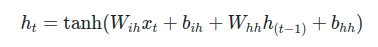

### 引数
以下の引数を設定することが可能です。

・入力サイズ(input_size ) ： 入力 x の特徴量の大きさ（入力必須）

・隠れ層のサイズ(hidden_size)： 隠れ層の特徴量の数（入力必須）  

・層の数(num_layers)：再帰層の数（デフォルト＝1）  

・非線形活性化関数(nonlinearity)：'tanh' もしくは 'relu'（デフォルト＝'tanh'）  

・バイアス(bias)：'True' もしくは 'False'（デフォルト＝'True'）  

・バッチファースト(batch_first)： 'False' もしくは'True' （デフォルト＝'False'）   
※True の場合、通常の (seq, batch, feature) の順から(batch, seq, feature) としてデータ構造を受け入れるようにする。注意：隠れ層には適用されない。  

・ドロップアウト(dropout) ： 0.0 ~ 1.0 (デフォルト＝0）  

・双方向性(bidirectional)：'False' もしくは'True' （デフォルト＝'False'）   
※Trueの場合、双方向RNNになる。

### 入力と出力
入力と出力は以下の形となります。

入力  
Inputs ：input, h_0  
input = (L,N,Hin)   
h_0 = (D∗num_layers,N,Hout)

出力  
Outputs：output, h_n  
output = (L,N,D∗Hout)  
h_n = (D∗num_layers,N,Hout)

L=シークエンス長
N=バッチサイズ
D=通常:1, 双方向:2  
Hin=入力サイズ  
Hout=隠れサイズ  
​


In [ ]:
from torch import nn
import torch

# RNN のインスタンスを作成します
rnn = nn.RNN(10, 20, 2)
# インプット
input = torch.randn(5, 3, 10)
h0 = torch.randn(2, 3, 20)
# アウトプット
output, hn = rnn(input, h0)

print('input:', input.shape)
print('h0:', h0.shape)
print('output:', output.shape)
print('hn:',hn.shape)

### dropout の追加

In [ ]:
rnn = nn.RNN(10, 20, 2, dropout=0.2)
input = torch.randn(5, 3, 10)
h0 = torch.randn(2, 3, 20)
output, hn = rnn(input, h0)

### 双方向RNN

In [ ]:
rnn = nn.RNN(10, 20, 2, bidirectional=True)
input = torch.randn(5, 3, 10)
# 双方向になるので、隠れ層を２倍にする必要があります。
h0 = torch.randn(2*2, 3, 20)
output, hn = rnn(input, h0)

print('input:', input.shape)
print('h0:', h0.shape)
print('output:', output.shape)
print('hn:',hn.shape)